descriptive statistics suffix:ll

Original
  Count     : 135
  Mean      : 9.733059
  Std Dev   : 13.882743
  Min       : 0.726352
  Max       : 81.030449
  Median    : 3.610325

Visual-Optimized
  Count     : 135
  Mean      : 9.453932
  Std Dev   : 13.603342
  Min       : 0.696021
  Max       : 83.587715
  Median    : 3.243133

Feature-Optimized
  Count     : 135
  Mean      : 8.461779
  Std Dev   : 11.718082
  Min       : 0.631004
  Max       : 56.930752
  Median    : 2.791781


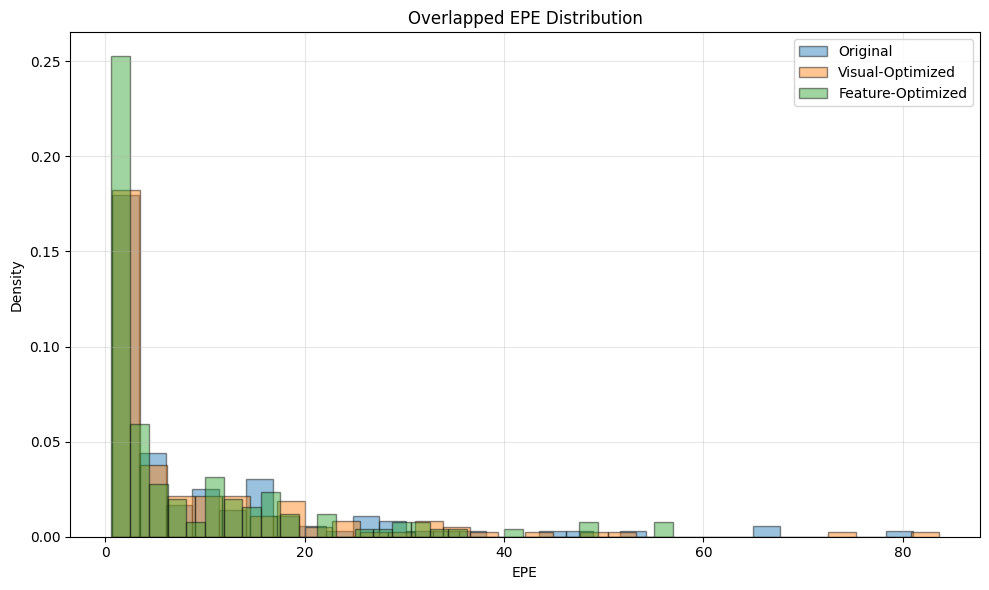

In [52]:
import itertools
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon
# ============================================================
# Input CSV paths
# ============================================================
# csv_paths = [
#     "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_sl_v16.2-chroma-ISPDefaultInitialHype_original_HpatchesV4.1",
#     "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_sl_v16.2-chroma-HumanTunedInitialHype_replicate-s21fe_sunlit_lr0.0005_schedulerPlateauTo0.00001_bs1_ga8_adjust_defaultcolorhuesat_120000_HpatchesV4.1",
#     "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_sl_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_sunlit_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32_105000_HpatchesV4.1",
# ]

csv_paths = [
    "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_ll_v16.2-chroma-ISPDefaultInitialHype_original_HpatchesV4.1",
    "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_ll_v16.2-chroma-HumanTunedInitialHype_replicate-s21fe_lowlight_lr0.0005_schedulerPlateauTo0.00001_bs1_ga8_adjust_defaultcolorhuesat_denoise_45000_HpatchesV4.1",
    "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_ll_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32_123000_HpatchesV4.1/"
]

exp_name = [
    "Original",
    "Visual-Optimized",
    "Feature-Optimized",
]

img_suffix = "ll"

csv_paths = [os.path.join(i, "aepe_list.csv") for i in csv_paths]

# ============================================================
# Load CSVs
# ============================================================
dfs = {}
for i,path in enumerate(csv_paths):
    name = exp_name[i]
    df = pd.read_csv(path)

    # Ensure EPE column exists
    if "EPE" not in df.columns:
        raise ValueError(f"'EPE' column not found in {path}")

    dfs[name] = df

# ============================================================
# Print statistics
# ============================================================
print("=" * 60)
print("descriptive statistics suffix:" + img_suffix)
print("=" * 60)

for name, df in dfs.items():
    epe = df["EPE"]

    print(f"\n{name}")
    print(f"  Count     : {len(epe)}")
    print(f"  Mean      : {epe.mean():.6f}")
    print(f"  Std Dev   : {epe.std():.6f}")
    print(f"  Min       : {epe.min():.6f}")
    print(f"  Max       : {epe.max():.6f}")
    print(f"  Median    : {epe.median():.6f}")

# ============================================================
# Overlapped histogram
# ============================================================
plt.figure(figsize=(10, 6))

bins = 30

for name, df in dfs.items():
    plt.hist(
        df["EPE"],
        bins=bins,
        alpha=0.45,
        density=True,
        label=name,
        edgecolor="black"
    )

plt.xlabel("EPE")
plt.ylabel("Density")
plt.title("Overlapped EPE Distribution")
# plt.legend(
#     loc="upper center",
#     bbox_to_anchor=(0.5, 1.15),
#     ncol=1,
#     frameon=False
# )
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"figures/discriptive_stat_histograms_{img_suffix}.png")
plt.show()


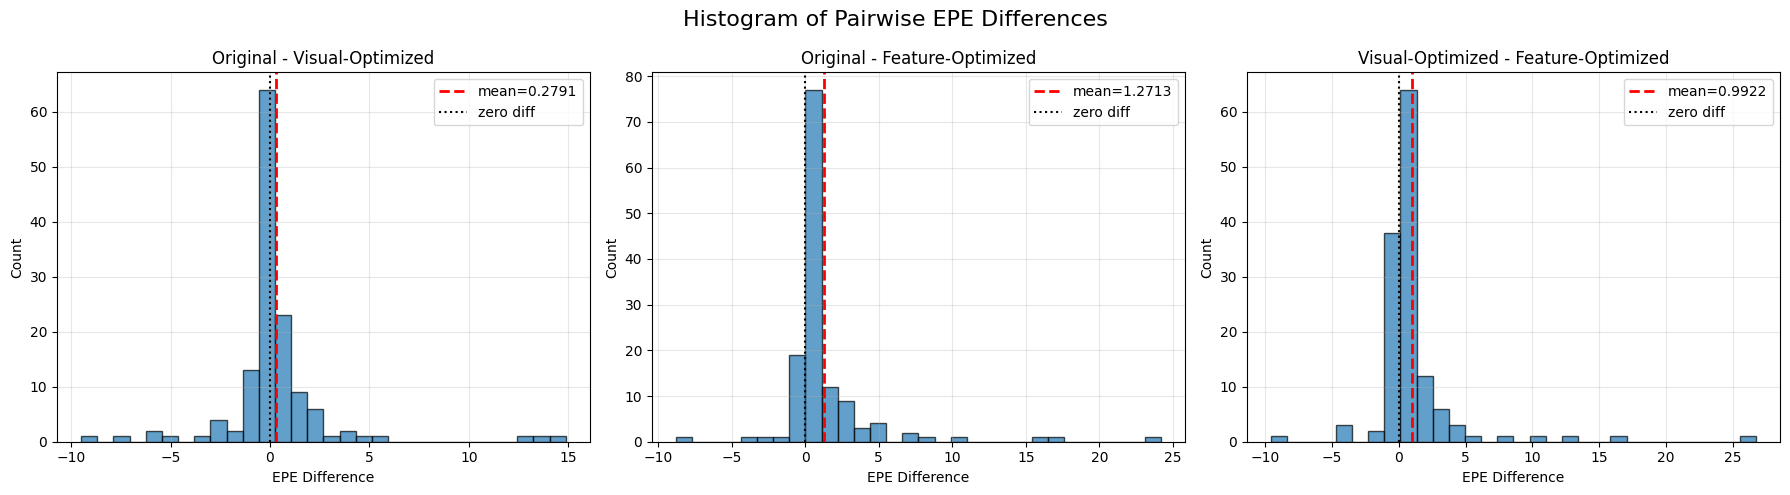

In [53]:
# ============================================================
# Plot histograms of pairwise differences
# diff = EPE(runA) - EPE(runB)
# ============================================================
pairs = list(itertools.combinations(dfs.keys(), 2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

keys = ["Sequence Name", "Viewpoint"]

for ax, (name1, name2) in zip(axes, pairs):

    df1 = dfs[name1][keys + ["EPE"]].rename(columns={"EPE": "EPE_1"})
    df2 = dfs[name2][keys + ["EPE"]].rename(columns={"EPE": "EPE_2"})

    merged = pd.merge(df1, df2, on=keys, how="inner")

    diff = merged["EPE_1"] - merged["EPE_2"]

    ax.hist(
        diff,
        bins=30,
        alpha=0.7,
        edgecolor="black"
    )

    ax.axvline(
        diff.mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"mean={diff.mean():.4f}"
    )

    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=1.5,
        label="zero diff"
    )

    ax.set_title(f"{name1} - {name2}")
    ax.set_xlabel("EPE Difference")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("Histogram of Pairwise EPE Differences", fontsize=16)

plt.tight_layout()
plt.show()

In [54]:

# ============================================================
# Pairwise significance tests
# ============================================================
print("\n" + "=" * 70)
print(f"PAIRWISE SIGNIFICANCE TESTS suffix:{img_suffix}")
print("=" * 70)

pairs = itertools.combinations(dfs.keys(), 2)

for a, b in pairs:
    x = dfs[a]["EPE"].values
    y = dfs[b]["EPE"].values

    # Paired t-test
    t_stat, t_p = ttest_rel(x, y)

    # Wilcoxon signed-rank test
    w_stat, w_p = wilcoxon(x, y)

    mean_diff = (x - y).mean()

    print(f"\n{a} vs {b}")
    print(f"  Mean Difference : {mean_diff:.6f}")
    print(f"  Paired t-test")
    print(f"    t-statistic   : {t_stat:.6f}")
    print(f"    p-value       : {t_p:.6e}")

    print(f"  Wilcoxon test")
    print(f"    statistic     : {w_stat:.6f}")
    print(f"    p-value       : {w_p:.6e}")

    # Simple interpretation
    alpha = 0.05

    if w_p < alpha:
        print("  => Significant difference (Wilcoxon, p < 0.05)")
    else:
        print("  => NOT statistically significant")


PAIRWISE SIGNIFICANCE TESTS suffix:ll

Original vs Visual-Optimized
  Mean Difference : 0.279126
  Paired t-test
    t-statistic   : 1.980069
    p-value       : 4.974436e-02
  Wilcoxon test
    statistic     : 2023.000000
    p-value       : 1.722255e-08
  => Significant difference (Wilcoxon, p < 0.05)

Original vs Feature-Optimized
  Mean Difference : 1.271280
  Paired t-test
    t-statistic   : 5.279574
    p-value       : 5.087910e-07
  Wilcoxon test
    statistic     : 292.000000
    p-value       : 3.744026e-21
  => Significant difference (Wilcoxon, p < 0.05)

Visual-Optimized vs Feature-Optimized
  Mean Difference : 0.992154
  Paired t-test
    t-statistic   : 4.293491
    p-value       : 3.350326e-05
  Wilcoxon test
    statistic     : 0.000000
    p-value       : 6.714005e-24
  => Significant difference (Wilcoxon, p < 0.05)
